# Step 3C — Zonal Market Model




In [1]:
import gurobipy as gp
from gurobipy import GRB
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

## 1. Conventional generators and network

In [2]:
# Conventional generators
G = list(range(12))

P_max = {
    0: 152, 1: 152, 2: 350, 3: 591, 4: 60, 5: 155,
    6: 155, 7: 400, 8: 400, 9: 300, 10: 310, 11: 350
}

C = {
    0: 13.32, 1: 13.32, 2: 20.70, 3: 20.93, 4: 26.11,
    5: 10.52, 6: 10.52, 7: 6.02, 8: 5.47, 9: 0.00,
    10: 10.52, 11: 10.89
}

# Single-hour demand and demand bid
D_total = 2650.5

# Buses
buses = list(range(1, 25))

# Generator-to-bus mapping
gen_bus = {
    0: 1,  1: 2,  2: 7,  3: 13, 4: 15, 5: 15,
    6: 16, 7: 18, 8: 21, 9: 22, 10: 23, 11: 23
}

# Line data with updated bottlenecks
line_data = [
    (1,2,175), (1,3,175), (1,5,350),
    (2,4,175), (2,6,175),
    (3,9,175), (3,24,400),
    (4,9,175),
    (5,10,350),
    (6,10,175),
    (7,8,350),
    (8,9,175), (8,10,175),
    (9,11,400), (9,12,400),
    (10,11,400), (10,12,400),
    (11,13,500), (11,14,500),
    (12,13,500), (12,23,500),
    (13,23,250),   # updated from 500 to 250
    (14,16,250),   # updated from 500 to 250
    (15,16,500), (15,21,400), (15,24,500),  # updated from 1000 to 400
    (16,17,500), (16,19,500),
    (17,18,500), (17,22,500),
    (18,21,1000),
    (19,20,1000),
    (20,23,1000),
    (21,22,500)
]

print("Number of generators:", len(G))
print("Number of buses:", len(buses))
print("Number of lines:", len(line_data))

Number of generators: 12
Number of buses: 24
Number of lines: 34


## 2. Zone definition

We keep the same 2-zone split used earlier:
- Zone A: buses 1–12
- Zone B: buses 13–24

In [3]:
ZONES = ["A", "B"]
bus_zone = {b: ("A" if b <= 12 else "B") for b in buses}

zone_buses = {
    z: [b for b in buses if bus_zone[b] == z]
    for z in ZONES
}
zone_buses

{'A': [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12],
 'B': [13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24]}

## 3. Distributed wind farms

Updated IEEE RTS-style setup:
- wind farms at buses 3, 5, 7, 16, 21, and 23
- each wind farm has 200 MW installed capacity

In [4]:
wind_nodes = [3, 5, 7, 16, 21, 23]
wind_cap = {n: 200.0 for n in wind_nodes}

pd.DataFrame({
    "wind_bus": wind_nodes,
    "capacity_MW": [wind_cap[n] for n in wind_nodes],
    "zone": [bus_zone[n] for n in wind_nodes]
})

# Wind availability data: read the SAME exported CSV used in the nodal notebook
import os
from pathlib import Path

candidate_paths = [
    Path("data/processed/wind_available_power_6_nodes_MW.csv"),
    Path("./data/processed/wind_available_power_6_nodes_MW.csv"),
    Path("../data/processed/wind_available_power_6_nodes_MW.csv"),
    Path("/mnt/data/data/processed/wind_available_power_6_nodes_MW.csv"),
    Path("/mnt/data/wind_available_power_6_nodes_MW.csv"),
]

wind_file = next((p for p in candidate_paths if p.exists()), None)

if wind_file is None:
    raise FileNotFoundError(
        "Could not find 'wind_available_power_6_nodes_MW.csv'. "
        "Place the exported CSV in data/processed/ or update candidate_paths."
    )

wind_data = pd.read_csv(wind_file)
print(f"Loaded wind data from: {wind_file}")
print("Available columns:", list(wind_data.columns))

node_to_col = {
    3: "wind_3",
    5: "wind_5",
    7: "wind_7",
    16: "wind_16",
    21: "wind_21",
    23: "wind_23",
}

required_cols = list(node_to_col.values())
missing_cols = [c for c in required_cols if c not in wind_data.columns]
if missing_cols:
    raise ValueError(f"Missing expected wind columns in CSV: {missing_cols}")

hours = list(range(len(wind_data)))
wind_avail = {
    n: {h: float(wind_data.loc[h, node_to_col[n]]) for h in hours}
    for n in wind_nodes
}

print("Wind availability imported directly from CSV for the six wind buses.")


Loaded wind data from: data\processed\wind_available_power_6_nodes_MW.csv
Available columns: ['hour', 'wind_3', 'wind_5', 'wind_7', 'wind_16', 'wind_21', 'wind_23']
Wind availability imported directly from CSV for the six wind buses.


## 4. Choose the study hour

In [5]:
# Use the same hour as in Assignment1_3nodal.ipynb
# Change this only if you also change it in the nodal notebook.
t_star = 18

if t_star not in hours:
    raise IndexError(f"Selected hour {t_star} is outside the CSV range 0..{len(hours)-1}")

print("Selected hour:", t_star)
print("Wind availability at selected hour:")
for n in wind_nodes:
    print(f"Bus {n}: {wind_avail[n][t_star]:.2f} MW")


Selected hour: 18
Wind availability at selected hour:
Bus 3: 56.85 MW
Bus 5: 64.45 MW
Bus 7: 84.63 MW
Bus 16: 33.48 MW
Bus 21: 65.02 MW
Bus 23: 81.37 MW


## 5. Nodal demand distribution and zonal demand aggregation

We first distribute the total system demand to load buses, then aggregate it to zones.

In [6]:
load_percent = {
    1:3.8, 2:3.4, 3:6.3, 4:2.6, 5:2.5,
    6:4.8, 7:4.4, 8:6.0, 9:6.1, 10:6.8,
    13:9.3, 14:6.8, 15:11.1, 16:3.5,
    18:11.7, 19:6.4, 20:4.5
}

load_share = {n: load_percent[n] / 100 for n in load_percent}
print("Sum of load shares:", sum(load_share.values()))

# Build nodal utility exactly as in the nodal model
U_bus = {n: 8 + 200 * load_share[n] for n in load_share}

# Demand at each bus
D_bus = {n: D_total * load_share.get(n, 0.0) for n in buses}

# Aggregate bus demands to zones
demand_in_zone = {z: 0.0 for z in ZONES}
for b in buses:
    demand_in_zone[bus_zone[b]] += D_bus[b]

# Load-weighted zonal utility
bid_in_zone = {}
for z in ZONES:
    buses_in_z = [b for b in buses if bus_zone[b] == z and D_bus.get(b, 0.0) > 0]
    if demand_in_zone[z] > 0:
        bid_in_zone[z] = sum(U_bus[b] * D_bus[b] for b in buses_in_z) / demand_in_zone[z]
    else:
        bid_in_zone[z] = 0.0

print("Demand in zones and zonal utility bids:")
for z in ZONES:
    print(f"Zone {z}: demand={demand_in_zone[z]:.2f} MW | bid={bid_in_zone[z]:.2f} EUR/MWh")

Sum of load shares: 1.0
Demand in zones and zonal utility bids:
Zone A: demand=1237.78 MW | bid=18.30 EUR/MWh
Zone B: demand=1412.72 MW | bid=25.50 EUR/MWh


## 6. Aggregate wind to zones for the selected hour

In [7]:
wind_in_zone = {z: 0.0 for z in ZONES}
for n in wind_nodes:
    z = bus_zone[n]
    wind_in_zone[z] += wind_avail[n][t_star]

wind_zone_df = pd.DataFrame({
    "Zone": list(ZONES),
    "Wind available (MW)": [wind_in_zone[z] for z in ZONES]
})

print("Wind in zones for the selected CSV hour:")
display(wind_zone_df)


Wind in zones for the selected CSV hour:


,Zone,Wind available (MW)
0,A,205.9324
1,B,179.8756


## 7. Compute ATC from interzonal lines

In [8]:
def compute_atc_from_line_data(line_data, bus_zone):
    atc = {}
    crossing_lines = []

    for (i, j, cap) in line_data:
        zi = bus_zone[i]
        zj = bus_zone[j]

        if zi != zj:
            key = tuple(sorted((zi, zj)))
            atc[key] = atc.get(key, 0.0) + float(cap)
            crossing_lines.append((i, j, cap, zi, zj))

    return atc, crossing_lines

atc, crossing_lines = compute_atc_from_line_data(line_data, bus_zone)

print("ATC between zones:", atc)
print("\nInterzonal lines:")
for row in crossing_lines:
    print(row)

ATC between zones: {('A', 'B'): 2400.0}

Interzonal lines:
(3, 24, 400, 'A', 'B')
(11, 13, 500, 'A', 'B')
(11, 14, 500, 'A', 'B')
(12, 13, 500, 'A', 'B')
(12, 23, 500, 'A', 'B')


## 8. Zonal market-clearing model

In [9]:
def solve_zonal_market(
    ZONES, atc, G, C, P_max, gen_bus, bus_zone,
    demand_in_zone, bid_in_zone, wind_in_zone,
    atc_scale=1.0, verbose=False
):
    m = gp.Model("ZonalMarket")
    m.Params.OutputFlag = 1 if verbose else 0

    # Conventional generation
    p = m.addVars(G, lb=0.0, ub={i: P_max[i] for i in G}, name="p")

    # Wind dispatched per zone
    pw = m.addVars(ZONES, lb=0.0, ub=wind_in_zone, name="pw")

    # Demand served per zone
    d = m.addVars(ZONES, lb=0.0, ub=demand_in_zone, name="d")

    # Interzonal flows
    flow = {}
    for (a, b), cap in atc.items():
        cap_eff = atc_scale * float(cap)
        flow[(a, b)] = m.addVar(lb=-cap_eff, ub=cap_eff, name=f"f_{a}_{b}")

    # Objective: minimize cost - utility
    m.setObjective(
        gp.quicksum(C[i] * p[i] for i in G)
        - gp.quicksum(bid_in_zone[z] * d[z] for z in ZONES),
        GRB.MINIMIZE
    )

    # Zonal balances
    balance = {}
    for z in ZONES:
        gen_in_z = gp.quicksum(p[i] for i in G if bus_zone[gen_bus[i]] == z)

        net_import = 0
        for (a, b), fvar in flow.items():
            # positive f_(a,b): power from a to b
            if z == a:
                net_import += -fvar
            elif z == b:
                net_import += fvar

        balance[z] = m.addConstr(
            gen_in_z + pw[z] + net_import == d[z],
            name=f"balance_{z}"
        )

    m.optimize()

    if m.status != GRB.OPTIMAL:
        raise RuntimeError(f"Model not optimal. Status = {m.status}")

    prices = {z: balance[z].Pi for z in ZONES}
    flow_val = {k: v.X for k, v in flow.items()}
    total_cost = sum(C[i] * p[i].X for i in G)
    total_utility = sum(bid_in_zone[z] * d[z].X for z in ZONES)
    welfare = total_utility - total_cost

    return {
        "prices": prices,
        "flow_val": flow_val,
        "total_cost": total_cost,
        "welfare": welfare,
        "gen": {i: p[i].X for i in G},
        "wind": {z: pw[z].X for z in ZONES},
        "demand": {z: d[z].X for z in ZONES},
    }

## 9. Run the zonal model for the selected hour

In [10]:
res = solve_zonal_market(
    ZONES=ZONES,
    atc=atc,
    G=G,
    C=C,
    P_max=P_max,
    gen_bus=gen_bus,
    bus_zone=bus_zone,
    demand_in_zone=demand_in_zone,
    bid_in_zone=bid_in_zone,
    wind_in_zone=wind_in_zone,
    atc_scale=1.0,
    verbose=False
)

print("Selected hour:", t_star)
print("Zonal prices (EUR/MWh):", res["prices"])
print("Interzonal flows (MW):", res["flow_val"])
print(f"Total generation cost (EUR): {res['total_cost']:.2f}")
print(f"Social welfare (EUR): {res['welfare']:.2f}")
print("Wind dispatched by zone (MW):", res["wind"])

Restricted license - for non-production use only - expires 2026-11-23
Selected hour: 18
Zonal prices (EUR/MWh): {'A': 13.32, 'B': 13.32}
Interzonal flows (MW): {('A', 'B'): -837.1590999999996}
Total generation cost (EUR): 17523.20
Social welfare (EUR): 41150.39
Wind dispatched by zone (MW): {'A': 205.9324, 'B': 179.8756}


## 10. ATC sensitivity analysis

In [11]:
scales = [0.0, 0.1, 0.25, 0.5, 1.0, 2.0, 10.0]

rows = []
for s in scales:
    out = solve_zonal_market(
        ZONES=ZONES,
        atc=atc,
        G=G,
        C=C,
        P_max=P_max,
        gen_bus=gen_bus,
        bus_zone=bus_zone,
        demand_in_zone=demand_in_zone,
        bid_in_zone=bid_in_zone,
        wind_in_zone=wind_in_zone,
        atc_scale=s,
        verbose=False
    )

    row = {
        "ATC_scale": s,
        "Welfare": out["welfare"],
        "Cost": out["total_cost"]
    }

    for z in ZONES:
        row[f"lambda_{z}"] = out["prices"][z]

    for (a, b), v in out["flow_val"].items():
        row[f"flow_{a}_{b}"] = v

    rows.append(row)

df = pd.DataFrame(rows)
df

,ATC_scale,Welfare,Cost,lambda_A,lambda_B,flow_A_B
0,0.00,35309.744291,10042.766268,18.301927,10.52,-0.0000
1,0.10,37177.406818,12567.566268,18.301927,10.52,-240.0000
2,0.25,39937.149475,16396.517401,18.301927,10.89,-600.0000
3,0.50,41150.390960,17523.197440,13.320000,13.32,-837.1591
4,1.00,41150.390960,17523.197440,13.320000,13.32,-837.1591
5,2.00,41150.390960,17523.197440,13.320000,13.32,-837.1591
6,10.00,41150.390960,17523.197440,13.320000,13.32,-837.1591


## 11. Plot zonal prices vs. ATC

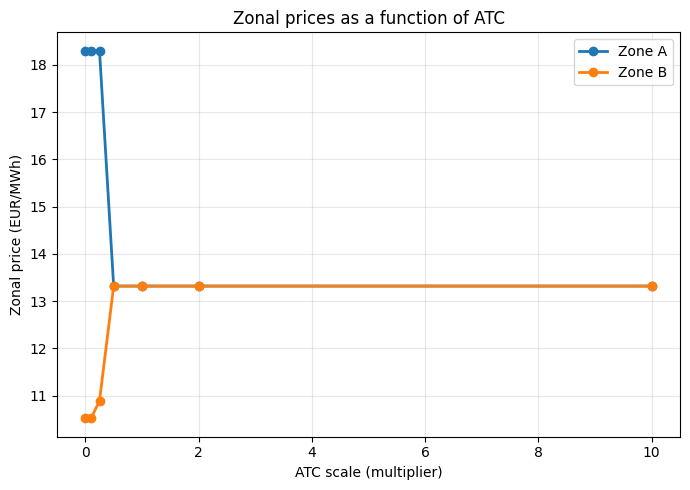

In [12]:
plt.figure(figsize=(7, 5))

for z in ZONES:
    plt.plot(
        df["ATC_scale"],
        df[f"lambda_{z}"],
        marker="o",
        linewidth=2,
        markersize=6,
        label=f"Zone {z}"
    )

plt.xlabel("ATC scale (multiplier)")
plt.ylabel("Zonal price (EUR/MWh)")
plt.title("Zonal prices as a function of ATC")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

## 12. Nodal vs. zonal comparison

The average nodal price in each zone is compared with the corresponding zonal market price for the same study hour and network assumptions.

In [13]:

import json


# -----------------------------
# Load nodal results
# -----------------------------
with open("nodal_results.json", "r") as f:
    nodal_data = json.load(f)

lambda_nodal = {int(k): float(v) for k, v in nodal_data["lambda"].items()}
nodal_total_cost = float(nodal_data["total_cost"])
nodal_welfare = float(nodal_data["welfare"])

# -----------------------------
# Rebuild zones if needed
# -----------------------------
buses = list(range(1, 25))
bus_zone = {b: ("A" if b <= 12 else "B") for b in buses}
ZONES = ["A", "B"]

# -----------------------------
# Stronger nodal-vs-zonal comparison
# -----------------------------
zone_rows = []
bus_rows = []

for z in ZONES:
    buses_in_z = [b for b in buses if bus_zone[b] == z]
    nodal_prices_z = [lambda_nodal[b] for b in buses_in_z]
    zonal_price_z = float(res["prices"][z])

    avg_nodal = float(np.mean(nodal_prices_z))
    min_nodal = float(np.min(nodal_prices_z))
    max_nodal = float(np.max(nodal_prices_z))
    inside_range = (min_nodal <= zonal_price_z <= max_nodal)

    zone_rows.append({
        "Zone": z,
        "Min nodal price": min_nodal,
        "Avg nodal price": avg_nodal,
        "Max nodal price": max_nodal,
        "Zonal price": zonal_price_z,
        "Inside nodal range?": "Yes" if inside_range else "No",
        "Zonal - Avg nodal": zonal_price_z - avg_nodal
    })

    for b in buses_in_z:
        bus_rows.append({
            "Zone": z,
            "Bus": b,
            "Nodal price": lambda_nodal[b],
            "Zonal price": zonal_price_z,
            "Absolute difference": abs(zonal_price_z - lambda_nodal[b])
        })

zone_compare_df = pd.DataFrame(zone_rows)
bus_compare_df = pd.DataFrame(bus_rows).sort_values(
    ["Zone", "Absolute difference"], ascending=[True, False]
)

print("Zone-level comparison:")
display(zone_compare_df)

print("\nBus-level comparison (largest differences first):")
display(bus_compare_df)

# Top mismatches per zone
top_mismatch_df = (
    bus_compare_df.groupby("Zone", group_keys=False)
    .head(3)
    .reset_index(drop=True)
)

print("\nTop 3 bus mismatches in each zone:")
display(top_mismatch_df)

for _, row in zone_compare_df.iterrows():
    print(
        f"Zone {row['Zone']}: zonal price = {row['Zonal price']:.2f}, "
        f"nodal range = [{row['Min nodal price']:.2f}, {row['Max nodal price']:.2f}], "
        f"inside range? {row['Inside nodal range?']}"
    )

Zone-level comparison:


,Zone,Min nodal price,Avg nodal price,Max nodal price,Zonal price,Inside nodal range?,Zonal - Avg nodal
0,A,13.32,13.32,13.32,13.32,Yes,1.776357e-15
1,B,13.32,13.32,13.32,13.32,Yes,-1.776357e-15



Bus-level comparison (largest differences first):


,Zone,Bus,Nodal price,Zonal price,Absolute difference
3,A,4,13.32,13.32,3.552714e-15
8,A,9,13.32,13.32,3.552714e-15
5,A,6,13.32,13.32,1.776357e-15
6,A,7,13.32,13.32,1.776357e-15
7,A,8,13.32,13.32,1.776357e-15
9,A,10,13.32,13.32,1.776357e-15
11,A,12,13.32,13.32,1.776357e-15
0,A,1,13.32,13.32,0.000000e+00
1,A,2,13.32,13.32,0.000000e+00
2,A,3,13.32,13.32,0.000000e+00



Top 3 bus mismatches in each zone:


,Zone,Bus,Nodal price,Zonal price,Absolute difference
0,A,4,13.32,13.32,3.552714e-15
1,A,9,13.32,13.32,3.552714e-15
2,A,6,13.32,13.32,1.776357e-15
3,B,15,13.32,13.32,7.105427e-15
4,B,17,13.32,13.32,7.105427e-15
5,B,18,13.32,13.32,7.105427e-15


Zone A: zonal price = 13.32, nodal range = [13.32, 13.32], inside range? Yes
Zone B: zonal price = 13.32, nodal range = [13.32, 13.32], inside range? Yes


## Comparison of total cost and social welfare
This table compares total generation cost and social welfare under the nodal and zonal market formulations

In [14]:
summary_df = pd.DataFrame({
    "Framework": ["Nodal", "Zonal"],
    "Total cost (EUR)": [nodal_total_cost, res["total_cost"]],
    "Social welfare (EUR)": [nodal_welfare, res["welfare"]]
})

display(summary_df)

,Framework,Total cost (EUR),Social welfare (EUR)
0,Nodal,17523.19744,247526.80256
1,Zonal,17523.19744,41150.39096


## 13. Implications of nodal vs. zonal frameworks

This section evaluates how the nodal and zonal market designs differ in terms of:

- Generator profits (conventional and renewable)
- Social welfare
- Physical feasibility of zonal outcomes
- Required ex-post redispatch

### 13.1 Load nodal results

In [15]:
import json
import numpy as np
import pandas as pd

with open("nodal_results.json", "r") as f:
    nodal_data = json.load(f)

lambda_nodal = {int(k): float(v) for k, v in nodal_data["lambda"].items()}
nodal_total_cost = float(nodal_data["total_cost"])
nodal_welfare = float(nodal_data["welfare"])
nodal_gen_dispatch = {int(k): float(v) for k, v in nodal_data["gen_dispatch"].items()}
nodal_wind_dispatch_by_bus = {
    int(k): float(v) for k, v in nodal_data["wind_dispatch_by_bus"].items()
}

### 13.2 Conventional generator profits

In [16]:
conv_profit_rows = []

for i in G:
    b = gen_bus[i]
    z = bus_zone[b]

    p_nodal = nodal_gen_dispatch[i]
    p_zonal = float(res["gen"][i])

    price_nodal = lambda_nodal[b]
    price_zonal = float(res["prices"][z])

    revenue_nodal = price_nodal * p_nodal
    revenue_zonal = price_zonal * p_zonal

    cost_nodal = C[i] * p_nodal
    cost_zonal = C[i] * p_zonal

    profit_nodal = revenue_nodal - cost_nodal
    profit_zonal = revenue_zonal - cost_zonal

    conv_profit_rows.append({
        "Generator": i,
        "Bus": b,
        "Zone": z,
        "Profit nodal (EUR)": profit_nodal,
        "Profit zonal (EUR)": profit_zonal,
        "Delta (zonal - nodal)": profit_zonal - profit_nodal
    })

conv_profit_df = pd.DataFrame(conv_profit_rows)
display(conv_profit_df)

,Generator,Bus,Zone,Profit nodal (EUR),Profit zonal (EUR),Delta (zonal - nodal)
0,0,1,A,0.0,0.0,0.000000e+00
1,1,2,A,0.0,0.0,0.000000e+00
2,2,7,A,0.0,0.0,0.000000e+00
3,3,13,B,0.0,0.0,0.000000e+00
4,4,15,B,0.0,0.0,0.000000e+00
5,5,15,B,434.0,434.0,-1.364242e-12
6,6,16,B,434.0,434.0,-9.094947e-13
7,7,18,B,2920.0,2920.0,-2.728484e-12
8,8,21,B,3140.0,3140.0,-2.728484e-12
9,9,22,B,3996.0,3996.0,-2.273737e-12


### 13.3 Renewable generator profits

In [17]:
zonal_wind_bus_dispatch = {}

for z in ZONES:
    zone_wind_nodes = [n for n in wind_nodes if bus_zone[n] == z]
    total_avail_z = sum(wind_avail[n][t_star] for n in zone_wind_nodes)

    for n in zone_wind_nodes:
        share = wind_avail[n][t_star] / total_avail_z if total_avail_z > 0 else 0.0
        zonal_wind_bus_dispatch[n] = share * float(res["wind"][z])

renew_profit_rows = []

for w in wind_nodes:
    z = bus_zone[w]

    p_nodal = nodal_wind_dispatch_by_bus.get(w, 0.0)
    p_zonal = zonal_wind_bus_dispatch[w]

    price_nodal = lambda_nodal[w]
    price_zonal = float(res["prices"][z])

    renew_profit_rows.append({
        "Bus": w,
        "Profit nodal (EUR)": price_nodal * p_nodal,
        "Profit zonal (EUR)": price_zonal * p_zonal,
        "Delta (zonal - nodal)": price_zonal * p_zonal - price_nodal * p_nodal
    })

renew_profit_df = pd.DataFrame(renew_profit_rows)
display(renew_profit_df)

,Bus,Profit nodal (EUR),Profit zonal (EUR),Delta (zonal - nodal)
0,3,757.234008,757.234008,0.000000e+00
1,5,858.487320,858.487320,0.000000e+00
2,7,1127.298240,1127.298240,0.000000e+00
3,16,446.006880,446.006880,-1.705303e-13
4,21,866.066400,866.066400,-4.547474e-13
5,23,1083.869712,1083.869712,0.000000e+00


### 13.4 Profit and welfare summary

In [18]:
summary_df = pd.DataFrame({
    "Framework": ["Nodal", "Zonal"],
    "Total cost (EUR)": [nodal_total_cost, float(res["total_cost"])],
    "Social welfare (EUR)": [nodal_welfare, float(res["welfare"])],
    "Conventional profit (EUR)": [
        conv_profit_df["Profit nodal (EUR)"].sum(),
        conv_profit_df["Profit zonal (EUR)"].sum()
    ],
    "Renewable profit (EUR)": [
        renew_profit_df["Profit nodal (EUR)"].sum(),
        renew_profit_df["Profit zonal (EUR)"].sum()
    ]
})

display(summary_df)

,Framework,Total cost (EUR),Social welfare (EUR),Conventional profit (EUR),Renewable profit (EUR)
0,Nodal,17523.19744,247526.80256,12642.5,5138.96256
1,Zonal,17523.19744,41150.39096,12642.5,5138.96256


### 13.5 Feasibility of zonal dispatch on the nodal network

In [19]:
gen_at_bus = {b: 0.0 for b in buses}
for i in G:
    gen_at_bus[gen_bus[i]] += float(res["gen"][i])

wind_at_bus = {b: 0.0 for b in buses}
for w in wind_nodes:
    wind_at_bus[w] = zonal_wind_bus_dispatch[w]

net_injection = {
    b: gen_at_bus[b] + wind_at_bus[b] - D_bus.get(b, 0.0)
    for b in buses
}

print("Total imbalance:", sum(net_injection.values()))

Total imbalance: -5.684341886080802e-14


In [20]:
import gurobipy as gp
from gurobipy import GRB

def check_feasibility():
    m = gp.Model()
    m.Params.OutputFlag = 0

    theta = m.addVars(buses, lb=-GRB.INFINITY)
    fvar = {}

    for (i, j, cap) in line_data:
        fvar[(i, j)] = m.addVar(lb=-GRB.INFINITY)

    for (i, j, cap) in line_data:
        m.addConstr(fvar[(i, j)] == 500 * (theta[i] - theta[j]))

    for n in buses:
        flow_out = gp.quicksum(fvar[(i, j)] for (i, j, cap) in line_data if i == n)
        flow_in = gp.quicksum(fvar[(i, j)] for (i, j, cap) in line_data if j == n)
        m.addConstr(net_injection[n] == flow_out - flow_in)

    m.addConstr(theta[13] == 0)
    m.optimize()

    rows = []
    for (i, j, cap) in line_data:
        f = fvar[(i, j)].X
        violation = max(0, abs(f) - cap)
        rows.append({"Line": f"{i}-{j}", "Violation": violation})

    return pd.DataFrame(rows)

feas_df = check_feasibility()
display(feas_df)

,Line,Violation
0,1-2,0.000000
1,1-3,0.000000
2,1-5,0.000000
3,2-4,0.000000
4,2-6,0.000000
5,3-9,0.000000
6,3-24,0.000000
7,4-9,0.000000
8,5-10,0.000000
9,6-10,0.000000


### 13.6 Overloads and redispatch requirement

In [21]:
overloaded = feas_df[feas_df["Violation"] > 1e-6]

total_violation = overloaded["Violation"].sum()
max_violation = overloaded["Violation"].max() if len(overloaded) > 0 else 0

print("Number of overloaded lines:", len(overloaded))
print("Total overload (MW):", total_violation)
print("Max overload (MW):", max_violation)

redispatch_proxy = 0.5 * total_violation
print("Approx. redispatch needed (MW):", redispatch_proxy)

Number of overloaded lines: 3
Total overload (MW): 239.36042679313886
Max overload (MW): 87.21393661642378
Approx. redispatch needed (MW): 119.68021339656943
